In [1]:
import json, math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gemmi
from typing import Tuple
import itertools 
import py3Dmol

plt.rcParams['figure.dpi'] = 140
sns.set_context("talk")

json_path = "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AF3/AF3_run1_output/724928537.dbz6___a/724928537.dbz6___a_confidences.json"

In [2]:
def load_structure_and_plddt(path: str) -> Tuple[gemmi.Structure, pd.DataFrame]:
    """Load a structure from a CIF file and extract pLDDT scores into a DataFrame.
    Args:
        path (str): Path to the CIF file containing the structure.
    Returns:
        Tuple[gemmi.Structure, pd.DataFrame]: A tuple containing the loaded structure and the pLDDT DataFrame."""
    # Load the structure using gemmi
    structure = gemmi.read_structure(path)

    records = []
    for model_idx, model in enumerate(structure):
        for chain in model:
            chain_id = chain.name
            for res in chain:
                b_vals = []
                for atom in res:
                    if atom.element.name == "H":  # Exclude hydrogens
                        continue
                    b = atom.b_iso # b can be 0.0 if unset; keep it but skip NaN/None
                    if b is None or b != b: # Check for NaN
                        continue
                    b_vals.append(float(b))
                
                if not b_vals:
                    continue  # Skip residues with no valid B-factors

                res_plddt = float(np.mean(b_vals))
                  # Average B-factor as pLDDT

                seqnum = res.seqid.num
                icode = res.seqid.icode
                icode = "" if not icode or icode == "\x00" else icode

                records.append({
                    "model_index": model_idx,
                    "chain": chain_id,
                    "residue_name": res.name,
                    "residue_id": seqnum,
                    "icode": icode,
                    "plddt": res_plddt
                })

    df = pd.DataFrame(records)
    if not df.empty: # sort by model, chain, residue_id, then insertion code
        df = df.sort_values(["model_index", "chain", "residue_id", "icode"]).reset_index(drop=True)
    return structure, df

structure_path = "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AF3/AF3_run1_output/724928537.dbz6___a/724928537.dbz6___a_model.cif"
structure, plddt_df = load_structure_and_plddt(structure_path)

plddt_df.head()



,model_index,chain,residue_name,residue_id,icode,plddt
0,0,A,GLN,1,,51.377778
1,0,A,VAL,2,,70.591428
2,0,A,GLN,3,,74.308890
3,0,A,LEU,4,,82.170000
4,0,A,VAL,5,,84.570001


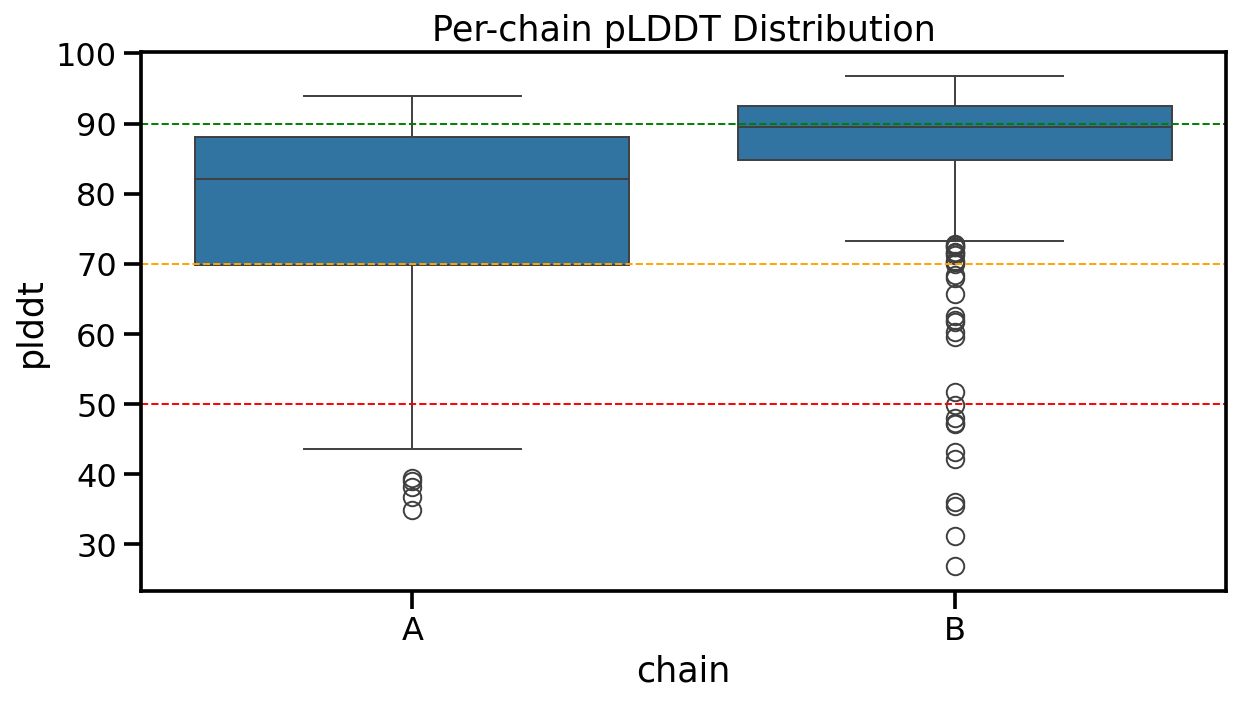

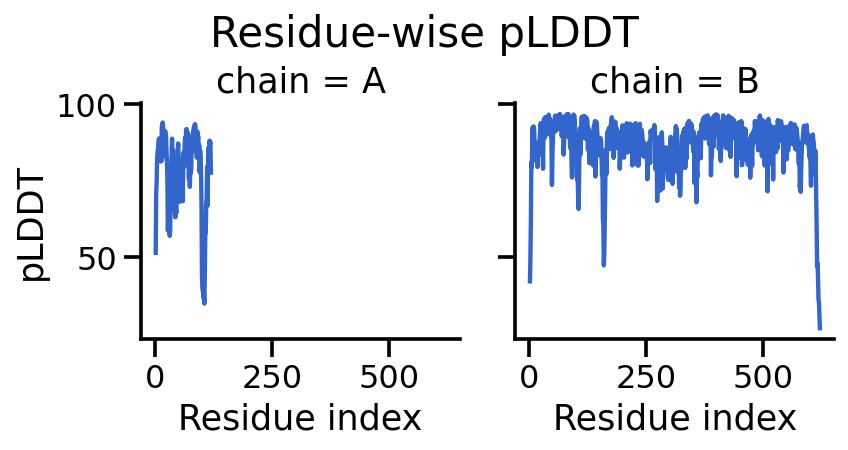

In [3]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=plddt_df, x="chain", y="plddt")
plt.axhline(90, color="g", lw=1, ls="--")
plt.axhline(70, color="orange", lw=1, ls="--")
plt.axhline(50, color="r", lw=1, ls="--")
plt.title("Per-chain pLDDT Distribution")
plt.show()

g = sns.FacetGrid(plddt_df, col="chain", col_wrap=2, sharey=True, height=3.2)
g.map_dataframe(sns.lineplot, x="residue_id", y="plddt", color="#3366cc")
g.set_ylabels("pLDDT")
g.set_xlabels("Residue index")
g.fig.suptitle("Residue-wise pLDDT", y=1.03)
plt.show()


In [ ]:
def view_structure_by_chain(path,
                            chain_colors={"A": "steelblue", "B": "orange"},
                            width=800,
                            height=600):
    """
    Visualize an mmCIF AlphaFold model in py3Dmol,
    coloring chains explicitly and using cartoon only.
    """
    with open(path, "r") as fh:
        cif_text = fh.read()

    v = py3Dmol.view(width=width, height=height)
    v.addModel(cif_text, "mmcif")

    # Clear any default styles
    v.setStyle({}, {})

    # Apply cartoon color per chain
    for chain_id, color in chain_colors.items():
        v.setStyle(
            {"chain": chain_id},
            {"sphere": {"color": color}}
        )

    v.zoomTo()
    return v


structure_path = "/home/postyr/Assessing-AI-Scoring-Accuracy-for-De-Novo-Proteins/results/AF3/AF3_run1_output/round1zeroshot.k5q_n70s_k71r_n73t_s87t_n88d_r179k_k183r_e213d_s214p/round1zeroshot.k5q_n70s_k71r_n73t_s87t_n88d_r179k_k183r_e213d_s214p_model.cif"
view_structure_by_chain(structure_path, chain_colors={"A": "cornflowerblue", "B": "tomato"})




3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
with open(json_path, "r") as f:
    conf = json.load(f)

for k in conf:
    print(k, type(conf[k]))

atom_chain_ids <class 'list'>
atom_plddts <class 'list'>
contact_probs <class 'list'>
pae <class 'list'>
token_chain_ids <class 'list'>
token_res_ids <class 'list'>


In [7]:
with open(json_path, "r") as f:
    conf = json.load(f)

pae = np.array(conf["pae"])
print("PAE shape:", pae.shape)

PAE shape: (740, 740)


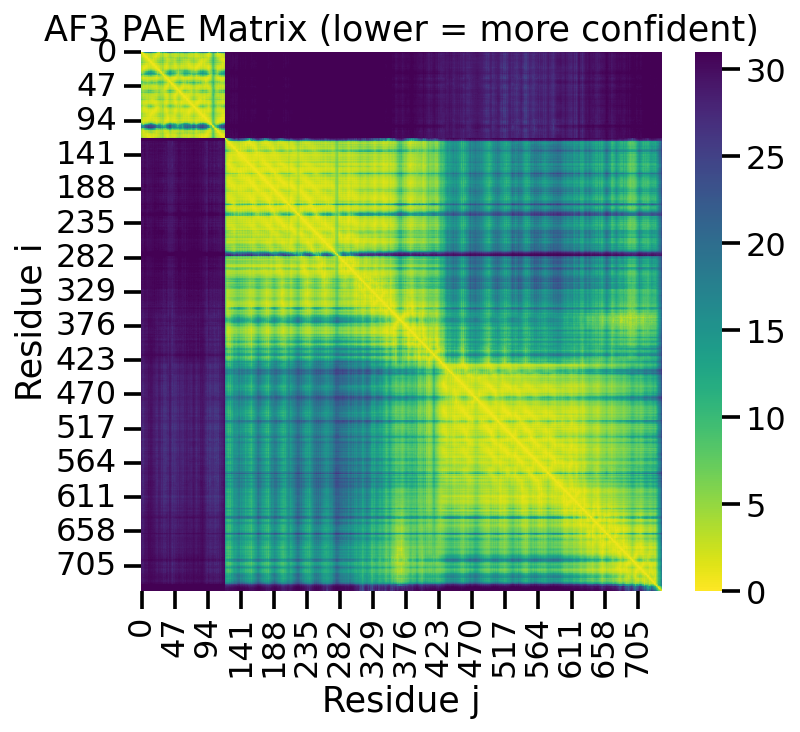

In [9]:
plt.figure(figsize=(6, 5))
sns.heatmap(pae, cmap="viridis_r", vmin=0, vmax=np.percentile(pae, 95))

plt.title("AF3 PAE Matrix (lower = more confident)")
plt.xlabel("Residue j")
plt.ylabel("Residue i")
plt.show()

In [15]:
token_chain_ids = np.array(conf["token_chain_ids"])
token_res_ids = np.array(conf["token_res_ids"])

chain_order = [cid for cid, _ in itertools.groupby(token_chain_ids)]
chain_ranges = {}

index = 0
for cid in chain_order:
    start = index
    count = np.sum(token_chain_ids == cid)
    end = start + count
    chain_ranges[cid] = (start, end)
    index = end

print("Chain order:", chain_order)
print("Chain ranges (token indices):", chain_ranges)

Chain order: [np.str_('A'), np.str_('B')]
Chain ranges (token indices): {np.str_('A'): (0, np.int64(119)), np.str_('B'): (np.int64(119), np.int64(740))}


In [ ]:
print(token_chain_ids)

['A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A'
 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'B' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B'
 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B' 'B

<function matplotlib.pyplot.show(close=None, block=None)>

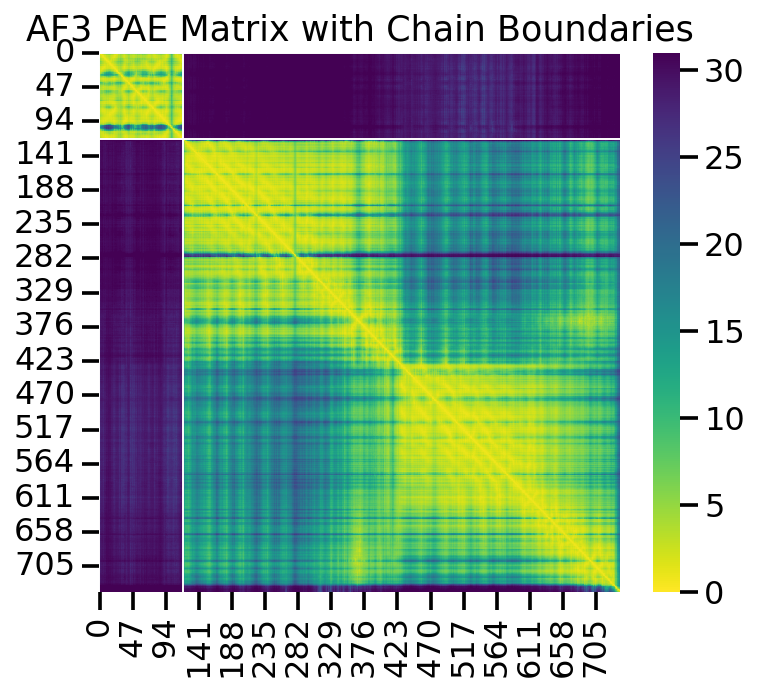

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(pae, cmap="viridis_r", vmin=0, vmax=np.percentile(pae, 95))

for cid, (start, end) in chain_ranges.items():
    plt.axvline(start, color="white", lw=1)
    plt.axhline(start, color="white", lw=1)

plt.title("AF3 PAE Matrix with Chain Boundaries")
plt.show